# 파트 1. 행사 종료 직후 지하철 승차 수요 비교

## 1. 분석 목적

대규모 행사 종료 직후 종합운동장역의 승차 인원이 평소보다 증가하는지 확인한다.

이번 파트에서는 행사일과 비행사일의 승차 수요 차이를 탐색적으로 비교하며, 통계적 유의성 검정이나 열차 증편 횟수 계산은 진행하지 않는다.

## 2. 분석 범위

- 분석 기간: 2022년~2025년 (코로나 시기인 2020, 2021년은 제외)
- 분석 역: 종합운동장역
- 분석 노선: 2호선, 9호선
- 주요 분석 대상: 승차 인원
- 행사 수요 시간대:
  - 행사 종료 시각이 포함된 시간대
  - 행사 종료 후 다음 1시간대

예를 들어 행사가 20시 30분에 종료된 경우, 20~21시와 21~22시 시간대를 분석한다.

## 3. 비교 기준

각 행사일의 승차 인원을 다음 조건이 같은 비행사일 평균과 비교한다.

- 같은 연도
- 같은 요일
- 같은 호선
- 같은 승하차 구분
- 같은 시간대

비행사일 기준값은 위 조건에 해당하는 비행사일 승차 인원의 평균으로 계산한다.

## 4. 주요 계산값

- 행사일 인원: 행사일 해당 시간대의 실제 승차 인원
- 비행사일 기준: 같은 조건의 비행사일 평균 승차 인원
- 증가 인원: 행사일 인원 - 비행사일 기준
- 증가율: 증가 인원 ÷ 비행사일 기준 × 100
- 행사일 우위 비율: 전체 행사 중 행사일 인원이 비행사일 기준보다 높았던 비율

## 5. 분석 과정

1. 행사일과 비행사일 구분
2. 행사 종료 시각 기준 시간대 설정
3. 비행사일 평균 기준값 계산
4. 행사일과 비행사일 승차 인원 비교
5. 호선별·요일별·행사 종료 시각별 차이 시각화
6. 결과 요약표 작성

## 6. 주요 시각화

- 행사일과 비행사일 평균 승차 인원 비교
- 요일별 승차 증가율
- 요일·행사 종료 시각별 승차 증가율 히트맵
- 요일·행사 종료 시각별 평균 승차 증가 인원 히트맵
- 행사일과 비행사일 승차 인원 분포 상자그림

## 7. 해석 시 주의사항

이번 분석은 행사일과 비행사일의 차이를 확인하는 탐색적 분석이다.

따라서 이 단계에서는 '행사 때문에 승차 인원이 증가했다'고 확정하기보다, '행사일에 승차 인원이 더 높게 나타나는 경향이 관찰됐다'고 해석한다.

통계적 유의성 검정, 혼잡도 분석, 열차 공급량 및 증편 횟수 계산은 이후 단계에서 별도로 진행한다.

### 전처리

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('3차통합.csv', encoding='utf-8-sig')
congestion_df = pd.read_csv('혼잡도_통합_v2.csv', encoding='utf-8-sig')

print(df.shape)
print(congestion_df.shape)
print(df.columns.tolist())

(175360, 29)
(912, 11)
['Unnamed: 0', '통합연번', '수송일자', '연도', '호선', '역번호', '역명', '승하차구분', '역ID', '역명_표준', '음수이상치여부', '월', '일', '요일번호', '요일', '공휴일여부', '요일구분', '시간대', '승하차인원', '피크타임', '시간대구분', '측정시작시간', '측정종료시간', '날짜', '제목', '분야명', '최초시작시간', '최종종료시간', '행사수']


In [48]:
# 코로나 시기로 범위 제한

df = df[df['연도'].between(2022, 2025)].copy()
df['수송일자'] = pd.to_datetime(df['수송일자'])

print(df['연도'].value_counts().sort_index())
print(df['수송일자'].min())
print(df['수송일자'].max())

연도
2022    29200
2023    29200
2024    29280
2025    29200
Name: count, dtype: int64
2022-01-01 00:00:00
2025-12-31 00:00:00


In [49]:
event_columns = ['수송일자', '제목', '분야명', '최초시작시간', '최종종료시간', '행사수']

event_info = df[df['제목'].notna()][event_columns].drop_duplicates('수송일자').copy()

event_info.head()

,수송일자,제목,분야명,최초시작시간,최종종료시간,행사수
12262,2024-10-13,도경수 아시아 팬 콘서트 투어,공연,4:00:00,6:30:00,1.0
29796,2024-10-12,도경수 아시아 팬 콘서트 투어,공연,6:00:00,8:30:00,1.0
38562,2024-10-11,도경수 아시아 팬 콘서트 투어,공연,7:00:00,9:30:00,1.0
80990,2022-11-05,태양의 써커스,공연,12:30:00,14:40:00,1.0
81004,2022-11-12,태양의 써커스,공연,12:30:00,14:40:00,1.0


In [ ]:
print(event_info.shape)
print(event_info['수송일자'].nunique())

(863, 6)
863


In [55]:
# 도경수 콘서트 시간 오류 수정

event_info.loc[event_info['수송일자'] == '2024-10-11', '최초시작시간'] = '19:00'
event_info.loc[event_info['수송일자'] == '2024-10-11', '최종종료시간'] = '21:30'

event_info.loc[event_info['수송일자'] == '2024-10-12', '최초시작시간'] = '18:00'
event_info.loc[event_info['수송일자'] == '2024-10-12', '최종종료시간'] = '20:30'

event_info.loc[event_info['수송일자'] == '2024-10-13', '최초시작시간'] = '16:00'
event_info.loc[event_info['수송일자'] == '2024-10-13', '최종종료시간'] = '18:30'

In [56]:
# 행사 시작, 종료 시각 생성

event_info['시작시'] = event_info['최초시작시간'].astype(str).str.split(':').str[0].astype(int)
event_info['종료시'] = event_info['최종종료시간'].astype(str).str.split(':').str[0].astype(int)
event_info['종료분'] = event_info['최종종료시간'].astype(str).str.split(':').str[1].astype(int)

event_info[['수송일자', '제목', '최초시작시간', '최종종료시간', '시작시', '종료시', '종료분']].head()

,수송일자,제목,최초시작시간,최종종료시간,시작시,종료시,종료분
12262,2024-10-13,도경수 아시아 팬 콘서트 투어,16:00,18:30,16,18,30
29796,2024-10-12,도경수 아시아 팬 콘서트 투어,18:00,20:30,18,20,30
38562,2024-10-11,도경수 아시아 팬 콘서트 투어,19:00,21:30,19,21,30
80990,2022-11-05,태양의 써커스,12:30:00,14:40:00,12,14,40
81004,2022-11-12,태양의 써커스,12:30:00,14:40:00,12,14,40


In [57]:
df = df.drop(columns=['제목', '분야명', '최초시작시간', '최종종료시간', '행사수'])
df = df.merge(event_info, on='수송일자', how='left')

df['행사여부'] = np.where(df['제목'].notna(), '행사일', '비행사일')

print(df['행사여부'].value_counts())
print('행사일 수:', df.loc[df['행사여부'] == '행사일', '수송일자'].nunique())
print('비행사일 수:', df.loc[df['행사여부'] == '비행사일', '수송일자'].nunique())

행사여부
행사일     69040
비행사일    47840
Name: count, dtype: int64
행사일 수: 863
비행사일 수: 598


In [58]:
# 중복, 이상값 확인

key_columns = ['수송일자', '호선', '승하차구분', '시간대']

print('중복 행 수:', df.duplicated(key_columns).sum())
print('음수 승하차 인원 수:', (df['승하차인원'] < 0).sum())

print(df[
    ['수송일자', '연도', '호선', '승하차구분', '요일', '시간대', '승하차인원']
].isna().sum())

중복 행 수: 0
음수 승하차 인원 수: 0
수송일자     0
연도       0
호선       0
승하차구분    0
요일       0
시간대      0
승하차인원    0
dtype: int64


In [61]:
# 시간대 정리

time_order = [
    '06시이전', '06-07시간대', '07-08시간대', '08-09시간대', '09-10시간대',
    '10-11시간대', '11-12시간대', '12-13시간대', '13-14시간대', '14-15시간대',
    '15-16시간대', '16-17시간대', '17-18시간대', '18-19시간대', '19-20시간대',
    '20-21시간대', '21-22시간대', '22-23시간대', '23-24시간대', '24시이후'
]

time_hour = {
    '06시이전': 5,
    '06-07시간대': 6,
    '07-08시간대': 7,
    '08-09시간대': 8,
    '09-10시간대': 9,
    '10-11시간대': 10,
    '11-12시간대': 11,
    '12-13시간대': 12,
    '13-14시간대': 13,
    '14-15시간대': 14,
    '15-16시간대': 15,
    '16-17시간대': 16,
    '17-18시간대': 17,
    '18-19시간대': 18,
    '19-20시간대': 19,
    '20-21시간대': 20,
    '21-22시간대': 21,
    '22-23시간대': 22,
    '23-24시간대': 23,
    '24시이후': 24
}

df['시간대시작'] = df['시간대'].map(time_hour)
df['시간대'] = pd.Categorical(df['시간대'], categories=time_order, ordered=True)

df[['시간대', '시간대시작']].drop_duplicates().sort_values('시간대')

,시간대,시간대시작
0,06시이전,5
5844,06-07시간대,6
11688,07-08시간대,7
17532,08-09시간대,8
23376,09-10시간대,9
29220,10-11시간대,10
35064,11-12시간대,11
40908,12-13시간대,12
46752,13-14시간대,13
52596,14-15시간대,14


In [62]:
# 요일 순서 정리

weekday_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']

df['요일'] = pd.Categorical(
    df['요일'],
    categories=weekday_order,
    ordered=True
)

df[['요일']].drop_duplicates().sort_values('요일')

,요일
4,월요일
6,화요일
8,수요일
10,목요일
12,금요일
0,토요일
2,일요일


In [63]:
# 연도별 행사/비행사 수 확인

date_count = (
    df[['수송일자', '연도', '행사여부']]
    .drop_duplicates()
    .groupby(['연도', '행사여부'], observed=True)
    .size()
    .unstack(fill_value=0)
)

date_count

행사여부,비행사일,행사일
연도,,
2022,152,213
2023,148,217
2024,148,218
2025,150,215


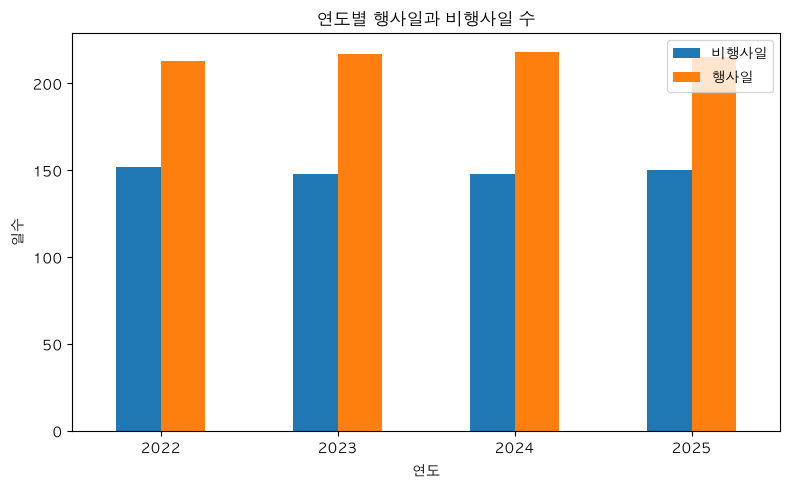

In [64]:
date_count.plot(kind='bar', figsize=(8, 5))

plt.title('연도별 행사일과 비행사일 수')
plt.xlabel('연도')
plt.ylabel('일수')
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.show()

In [66]:
# 전체 시간대별 행사일/비행사일 평균 승하차 고객 수 비교

hourly_average = (
    df.groupby(
        ['시간대', '호선', '승하차구분', '행사여부'],
        observed=True
    )['승하차인원']
    .mean()
    .reset_index(name='평균인원')
)

hourly_average.head()

,시간대,호선,승하차구분,행사여부,평균인원
0,06시이전,2호선,승차,비행사일,57.025084
1,06시이전,2호선,승차,행사일,54.118192
2,06시이전,2호선,하차,비행사일,38.361204
3,06시이전,2호선,하차,행사일,37.500579
4,06시이전,9호선,승차,비행사일,43.849498


### 승차

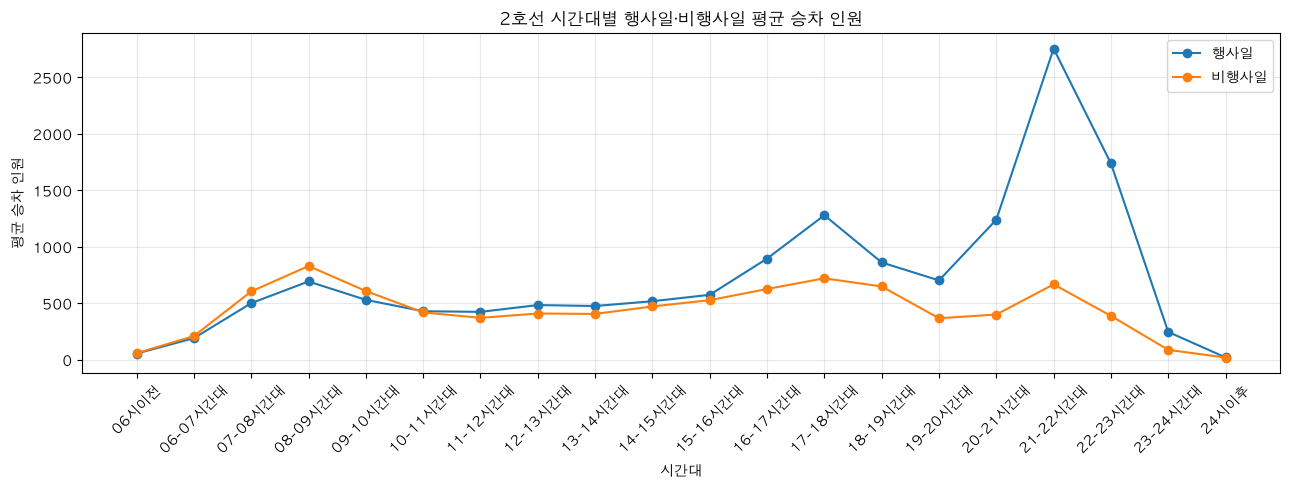

In [ ]:
# 2호선 승차 시각화

plot_data = hourly_average[
    (hourly_average['호선'] == '2호선') &
    (hourly_average['승하차구분'] == '승차')
]

plt.figure(figsize=(13, 5))

for event_type in ['행사일', '비행사일']:
    one = plot_data[plot_data['행사여부'] == event_type]

    plt.plot(
        one['시간대'].astype(str),
        one['평균인원'],
        marker='o',
        label=event_type
    )

plt.title('2호선 시간대별 행사일·비행사일 평균 승차 인원')
plt.xlabel('시간대')
plt.ylabel('평균 승차 인원')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

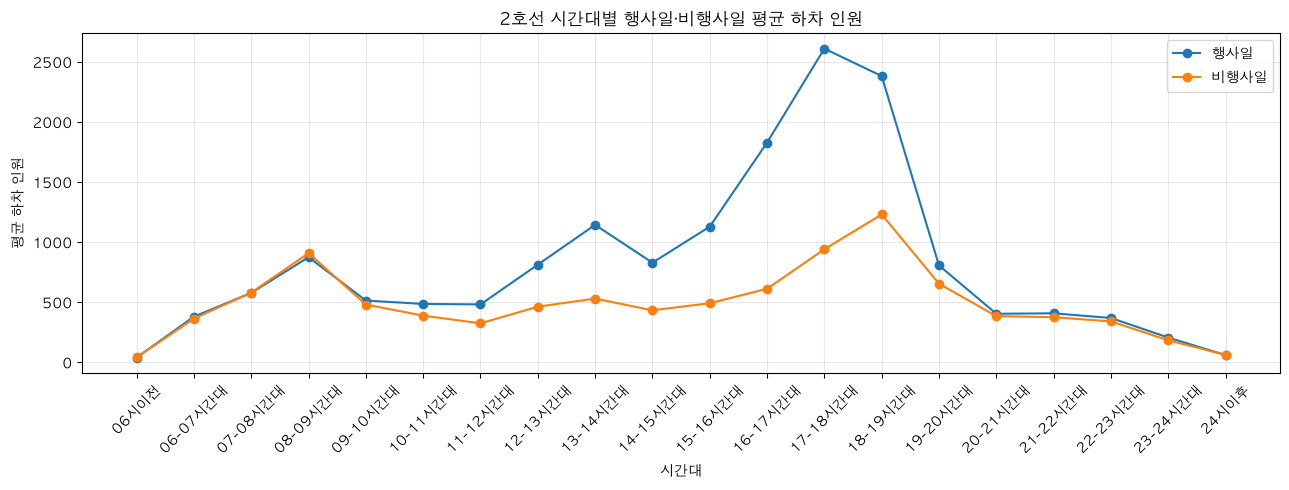

In [68]:
# 2호선 하차 시각화

plot_data = hourly_average[
    (hourly_average['호선'] == '2호선') &
    (hourly_average['승하차구분'] == '하차')
]

plt.figure(figsize=(13, 5))

for event_type in ['행사일', '비행사일']:
    one = plot_data[plot_data['행사여부'] == event_type]

    plt.plot(
        one['시간대'].astype(str),
        one['평균인원'],
        marker='o',
        label=event_type
    )

plt.title('2호선 시간대별 행사일·비행사일 평균 하차 인원')
plt.xlabel('시간대')
plt.ylabel('평균 하차 인원')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

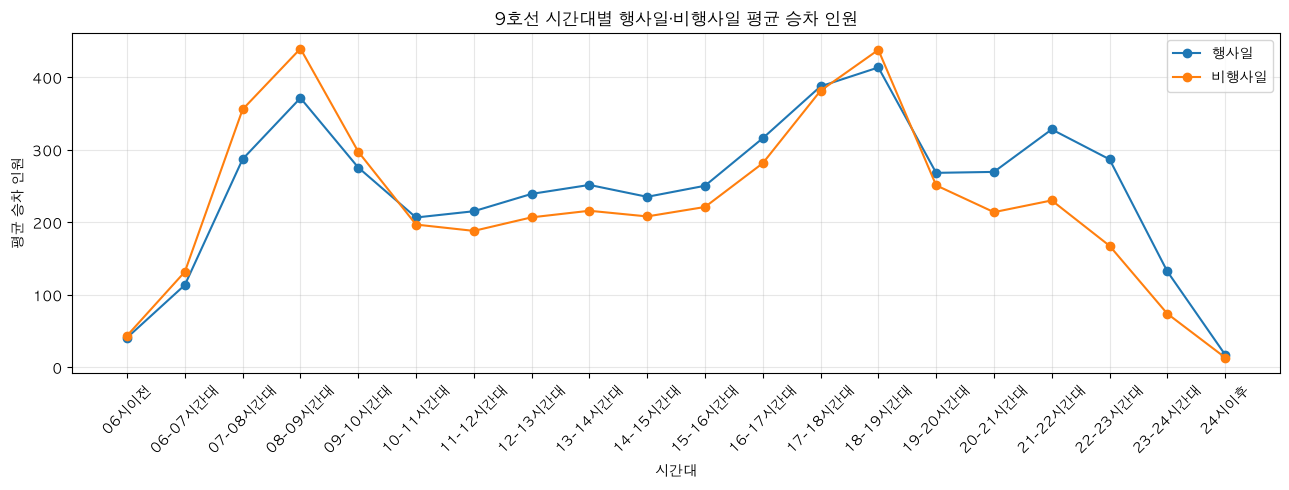

In [69]:
# 9호선 승차 시각화

plot_data = hourly_average[
    (hourly_average['호선'] == '9호선') &
    (hourly_average['승하차구분'] == '승차')
]

plt.figure(figsize=(13, 5))

for event_type in ['행사일', '비행사일']:
    one = plot_data[plot_data['행사여부'] == event_type]

    plt.plot(
        one['시간대'].astype(str),
        one['평균인원'],
        marker='o',
        label=event_type
    )

plt.title('9호선 시간대별 행사일·비행사일 평균 승차 인원')
plt.xlabel('시간대')
plt.ylabel('평균 승차 인원')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

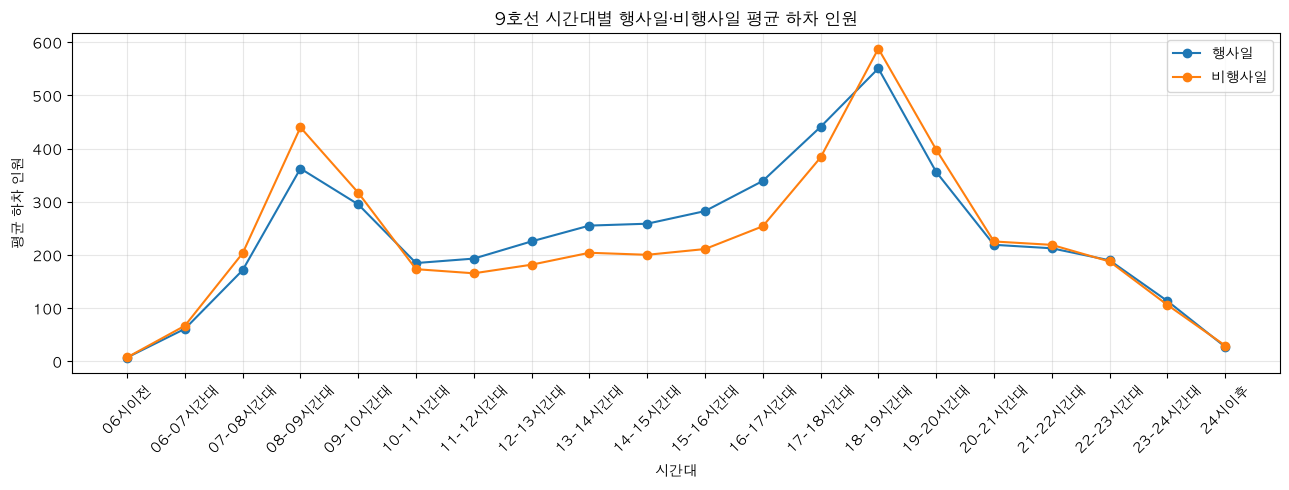

In [70]:
# 9호선 하차 시각화

plot_data = hourly_average[
    (hourly_average['호선'] == '9호선') &
    (hourly_average['승하차구분'] == '하차')
]

plt.figure(figsize=(13, 5))

for event_type in ['행사일', '비행사일']:
    one = plot_data[plot_data['행사여부'] == event_type]

    plt.plot(
        one['시간대'].astype(str),
        one['평균인원'],
        marker='o',
        label=event_type
    )

plt.title('9호선 시간대별 행사일·비행사일 평균 하차 인원')
plt.xlabel('시간대')
plt.ylabel('평균 하차 인원')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 행사 종료 시각 & 종료 후 한 시간 후 결합 (모든 시간대를 다 보여주려면 차트가 많을 거 같아서..)

event_rows = df[df['행사여부'] == '행사일'].copy()
event_rows['상대시간대'] = None

event_rows.loc[event_rows['시간대시작'] == event_rows['종료시'], '상대시간대'] = '종료 포함 시간대'
event_rows.loc[event_rows['시간대시작'] == event_rows['종료시'] + 1, '상대시간대'] = '종료 후 1시간대'

event_window = event_rows[event_rows['상대시간대'].notna()].copy()

print(event_window['상대시간대'].value_counts())
print('분석에 포함된 행사일 수:', event_window['수송일자'].nunique())

상대시간대
종료 포함 시간대    3452
종료 후 1시간대    3452
Name: count, dtype: int64
분석에 포함된 행사일 수: 863


In [73]:
# 비행사일 기준 평균

normal_days = df[df['행사여부'] == '비행사일'].copy()
baseline_keys = ['연도', '요일', '호선', '승하차구분', '시간대']
baseline = (
    normal_days.groupby(baseline_keys, observed=True)['승하차인원']
    .mean()
    .reset_index(name='비행사일평균')
)

baseline.head()


,연도,요일,호선,승하차구분,시간대,비행사일평균
0,2022,월요일,2호선,승차,06시이전,65.122449
1,2022,월요일,2호선,승차,06-07시간대,208.653061
2,2022,월요일,2호선,승차,07-08시간대,633.102041
3,2022,월요일,2호선,승차,08-09시간대,854.408163
4,2022,월요일,2호선,승차,09-10시간대,580.795918


In [75]:
# 행사 종료 직후 데이터 + 비행사일 평균 조인

matched = event_window.merge(
    baseline,
    on=['연도', '요일', '호선', '승하차구분', '시간대'],
    how='left'
)

matched[
    ['수송일자', '요일', '호선', '승하차구분', '시간대',
     '상대시간대', '승하차인원', '비행사일평균']
].head(10)

,수송일자,요일,호선,승하차구분,시간대,상대시간대,승하차인원,비행사일평균
0,2022-11-05,토요일,2호선,승차,14-15시간대,종료 포함 시간대,832,395.461538
1,2022-11-05,토요일,2호선,하차,14-15시간대,종료 포함 시간대,704,692.076923
2,2022-11-12,토요일,2호선,승차,14-15시간대,종료 포함 시간대,926,395.461538
3,2022-11-12,토요일,2호선,하차,14-15시간대,종료 포함 시간대,741,692.076923
4,2022-11-19,토요일,2호선,승차,14-15시간대,종료 포함 시간대,465,395.461538
5,2022-11-19,토요일,2호선,하차,14-15시간대,종료 포함 시간대,936,692.076923
6,2022-11-26,토요일,2호선,승차,14-15시간대,종료 포함 시간대,997,395.461538
7,2022-11-26,토요일,2호선,하차,14-15시간대,종료 포함 시간대,942,692.076923
8,2022-12-03,토요일,2호선,승차,14-15시간대,종료 포함 시간대,973,395.461538
9,2022-12-03,토요일,2호선,하차,14-15시간대,종료 포함 시간대,1960,692.076923


In [76]:
print('비행사일 평균이 없는 행 수:', matched['비행사일평균'].isna().sum())

비행사일 평균이 없는 행 수: 0


In [78]:
# 행사/비행사 차이, 증가율 차이 확인

matched['차이'] = matched['승하차인원'] - matched['비행사일평균']

matched['증가율'] = np.where(
    matched['비행사일평균'] > 0,
    matched['차이'] / matched['비행사일평균'] * 100,
    np.nan
)

matched[
    ['수송일자', '호선', '승하차구분', '시간대', '상대시간대',
     '승하차인원', '비행사일평균', '차이', '증가율']
].head(10)

,수송일자,호선,승하차구분,시간대,상대시간대,승하차인원,비행사일평균,차이,증가율
0,2022-11-05,2호선,승차,14-15시간대,종료 포함 시간대,832,395.461538,436.538462,110.387084
1,2022-11-05,2호선,하차,14-15시간대,종료 포함 시간대,704,692.076923,11.923077,1.722796
2,2022-11-12,2호선,승차,14-15시간대,종료 포함 시간대,926,395.461538,530.538462,134.156779
3,2022-11-12,2호선,하차,14-15시간대,종료 포함 시간대,741,692.076923,48.923077,7.069023
4,2022-11-19,2호선,승차,14-15시간대,종료 포함 시간대,465,395.461538,69.538462,17.584128
5,2022-11-19,2호선,하차,14-15시간대,종료 포함 시간대,936,692.076923,243.923077,35.245082
6,2022-11-26,2호선,승차,14-15시간대,종료 포함 시간대,997,395.461538,601.538462,152.110484
7,2022-11-26,2호선,하차,14-15시간대,종료 포함 시간대,942,692.076923,249.923077,36.112037
8,2022-12-03,2호선,승차,14-15시간대,종료 포함 시간대,973,395.461538,577.538462,146.041626
9,2022-12-03,2호선,하차,14-15시간대,종료 포함 시간대,1960,692.076923,1267.923077,183.205513


In [79]:
print('증가율 결측값 수:', matched['증가율'].isna().sum())
print('증가율 무한대 수:', np.isinf(matched['증가율']).sum())

증가율 결측값 수: 0
증가율 무한대 수: 0


In [ ]:
# 종료 포함 시간대와 종료 후 1시간대 평균

matched['행사일우위'] = matched['차이'] > 0


In [81]:
# 호선/승하차/상대시간대별 결과

time_summary = (
    matched.groupby(
        ['호선', '승하차구분', '상대시간대'],
        observed=True
    )
    .agg(
        행사일평균=('승하차인원', 'mean'),
        비행사일평균=('비행사일평균', 'mean'),
        평균차이=('차이', 'mean'),
        평균증가율=('증가율', 'mean'),
        증가율중앙값=('증가율', 'median'),
        행사일우위비율=('행사일우위', 'mean'),
        표본수=('수송일자', 'count')
    )
    .reset_index()
)

time_summary['행사일우위비율'] = time_summary['행사일우위비율'] * 100
time_summary.round(2)

,호선,승하차구분,상대시간대,행사일평균,비행사일평균,평균차이,평균증가율,증가율중앙값,행사일우위비율,표본수
0,2호선,승차,종료 포함 시간대,3130.90,749.86,2381.05,445.20,157.11,74.62,863
1,2호선,승차,종료 후 1시간대,1844.66,436.66,1408.00,480.77,81.69,66.16,863
2,2호선,하차,종료 포함 시간대,472.49,392.88,79.62,22.75,14.87,76.13,863
3,2호선,하차,종료 후 1시간대,392.09,345.77,46.32,19.74,12.66,76.25,863
4,9호선,승차,종료 포함 시간대,317.69,232.21,85.48,43.46,9.42,65.35,863
5,9호선,승차,종료 후 1시간대,317.86,181.70,136.16,89.50,24.52,77.40,863
6,9호선,하차,종료 포함 시간대,220.71,216.01,4.69,4.59,3.74,60.02,863
7,9호선,하차,종료 후 1시간대,197.13,190.03,7.11,8.34,6.96,67.21,863


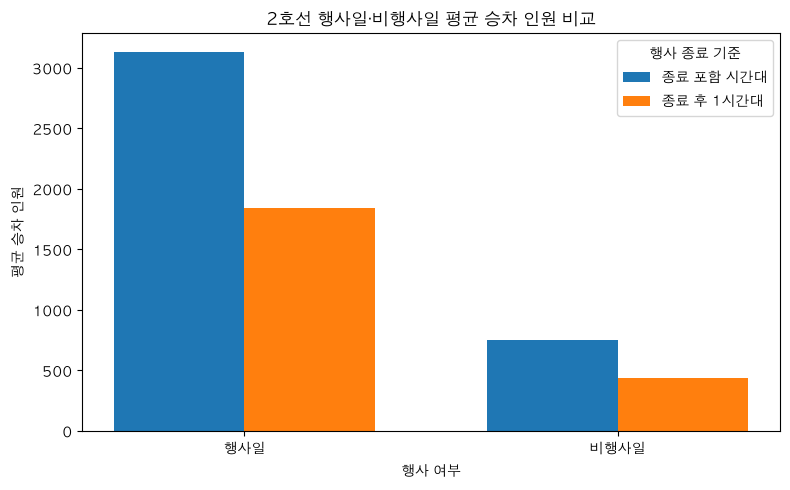

In [87]:
# 2호선 행사/비행사 평균 승차 인원 비교

plot_data = time_summary[
    (time_summary['호선'] == '2호선') &
    (time_summary['승하차구분'] == '승차')
].copy()

end_time = plot_data[plot_data['상대시간대'] == '종료 포함 시간대'].iloc[0]
after_time = plot_data[plot_data['상대시간대'] == '종료 후 1시간대'].iloc[0]

x_labels = ['행사일', '비행사일']

end_values = [
    end_time['행사일평균'],
    end_time['비행사일평균']
]

after_values = [
    after_time['행사일평균'],
    after_time['비행사일평균']
]

x = np.arange(len(x_labels))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    end_values,
    width=width,
    label='종료 포함 시간대'
)

plt.bar(
    x + width / 2,
    after_values,
    width=width,
    label='종료 후 1시간대'
)

plt.title('2호선 행사일·비행사일 평균 승차 인원 비교')
plt.xlabel('행사 여부')
plt.ylabel('평균 승차 인원')
plt.xticks(x, x_labels)
plt.legend(title='행사 종료 기준')
plt.tight_layout()
plt.show()

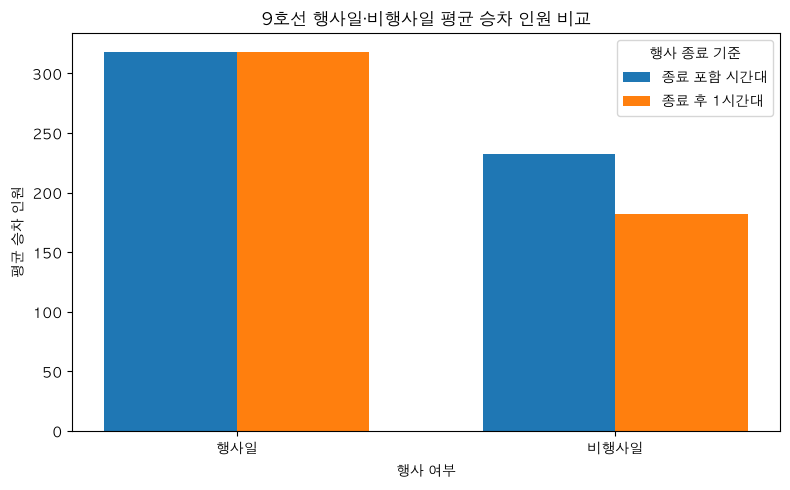

In [84]:
# 9호선 행사/비행사 평균 승차 인원 비교

plot_data = time_summary[
    (time_summary['호선'] == '9호선') &
    (time_summary['승하차구분'] == '승차')
].copy()

end_time = plot_data[plot_data['상대시간대'] == '종료 포함 시간대'].iloc[0]
after_time = plot_data[plot_data['상대시간대'] == '종료 후 1시간대'].iloc[0]

x_labels = ['행사일', '비행사일']

end_values = [
    end_time['행사일평균'],
    end_time['비행사일평균']
]

after_values = [
    after_time['행사일평균'],
    after_time['비행사일평균']
]

x = np.arange(len(x_labels))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    end_values,
    width=width,
    label='종료 포함 시간대'
)

plt.bar(
    x + width / 2,
    after_values,
    width=width,
    label='종료 후 1시간대'
)

plt.title('9호선 행사일·비행사일 평균 승차 인원 비교')
plt.xlabel('행사 여부')
plt.ylabel('평균 승차 인원')
plt.xticks(x, x_labels)
plt.legend(title='행사 종료 기준')
plt.tight_layout()
plt.show()


In [89]:
# 행사 종료 직후 두 시간대 행사별 합

daily_result = (
    matched.groupby(
        ['수송일자', '연도', '월', '요일', '요일구분', '호선', '승하차구분'],
        observed=True
    )
    .agg(
        행사일인원=('승하차인원', 'sum'),
        비행사일기준=('비행사일평균', 'sum')
    )
    .reset_index()
)

daily_result.head(10)

,수송일자,연도,월,요일,요일구분,호선,승하차구분,행사일인원,비행사일기준
0,2022-01-07,2022,1,금요일,평일,2호선,승차,605,2648.571429
1,2022-01-07,2022,1,금요일,평일,2호선,하차,815,846.071429
2,2022-01-07,2022,1,금요일,평일,9호선,승차,455,450.785714
3,2022-01-07,2022,1,금요일,평일,9호선,하차,436,385.000000
4,2022-01-09,2022,1,일요일,주말,2호선,승차,675,1498.000000
5,2022-01-09,2022,1,일요일,주말,2호선,하차,572,687.090909
6,2022-01-09,2022,1,일요일,주말,9호선,승차,441,265.727273
7,2022-01-09,2022,1,일요일,주말,9호선,하차,292,315.000000
8,2022-01-12,2022,1,수요일,평일,2호선,승차,560,1331.157895
9,2022-01-12,2022,1,수요일,평일,2호선,하차,808,716.263158


In [90]:
# 행사일별 차이와 증가율

daily_result['차이'] = daily_result['행사일인원'] - daily_result['비행사일기준']

daily_result['증가율'] = (
    daily_result['차이'] / daily_result['비행사일기준'] * 100
)

daily_result[
    ['수송일자', '호선', '승하차구분',
     '행사일인원', '비행사일기준', '차이', '증가율']
].head(10)

,수송일자,호선,승하차구분,행사일인원,비행사일기준,차이,증가율
0,2022-01-07,2호선,승차,605,2648.571429,-2043.571429,-77.157497
1,2022-01-07,2호선,하차,815,846.071429,-31.071429,-3.672436
2,2022-01-07,9호선,승차,455,450.785714,4.214286,0.934876
3,2022-01-07,9호선,하차,436,385.000000,51.000000,13.246753
4,2022-01-09,2호선,승차,675,1498.000000,-823.000000,-54.939920
5,2022-01-09,2호선,하차,572,687.090909,-115.090909,-16.750463
6,2022-01-09,9호선,승차,441,265.727273,175.272727,65.959631
7,2022-01-09,9호선,하차,292,315.000000,-23.000000,-7.301587
8,2022-01-12,2호선,승차,560,1331.157895,-771.157895,-57.931362
9,2022-01-12,2호선,하차,808,716.263158,91.736842,12.807701


In [91]:
print('비행사일 기준이 0인 행 수:', (daily_result['비행사일기준'] == 0).sum())
print('증가율 결측값 수:', daily_result['증가율'].isna().sum())
print('증가율 무한대 수:', np.isinf(daily_result['증가율']).sum())

비행사일 기준이 0인 행 수: 0
증가율 결측값 수: 0
증가율 무한대 수: 0


In [92]:
# 요일별 행사 종료 직후 승차 수요 증가 확인

weekday_summary = (
    daily_result[daily_result['승하차구분'] == '승차']
    .groupby(['요일', '호선'], observed=True)
    .agg(
        행사일평균=('행사일인원', 'mean'),
        비행사일평균=('비행사일기준', 'mean'),
        평균차이=('차이', 'mean'),
        증가율중앙값=('증가율', 'median'),
        표본수=('수송일자', 'count')
    )
    .reset_index()
)

weekday_summary.round(2)

,요일,호선,행사일평균,비행사일평균,평균차이,증가율중앙값,표본수
0,월요일,2호선,2279.73,773.59,1506.14,-0.19,22
1,월요일,9호선,653.55,527.41,126.13,6.61,22
2,화요일,2호선,5146.46,1152.36,3994.10,269.30,104
3,화요일,9호선,508.74,419.10,89.65,10.27,104
4,수요일,2호선,4798.90,1318.55,3480.35,209.96,131
5,수요일,9호선,515.64,396.54,119.11,11.54,131
6,목요일,2호선,4738.64,1363.88,3374.77,153.12,143
7,목요일,9호선,512.96,420.35,92.60,10.39,143
8,금요일,2호선,5777.72,1530.22,4247.50,169.85,142
9,금요일,9호선,649.07,438.69,210.38,13.22,142


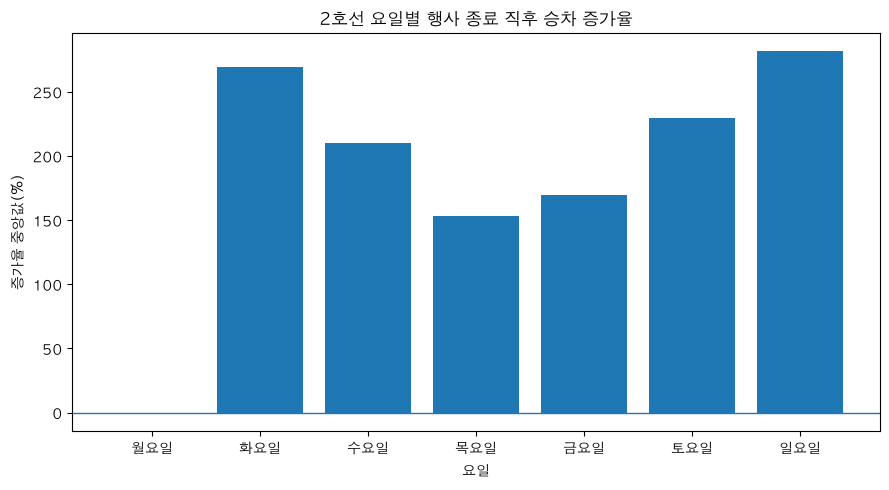

In [93]:
# 2호선 요일별 행사 종료 직후 승차 중가율 중앙값

plot_data = weekday_summary[
    weekday_summary['호선'] == '2호선'
].copy()

plt.figure(figsize=(9, 5))

plt.bar(
    plot_data['요일'].astype(str),
    plot_data['증가율중앙값']
)

plt.axhline(0, linewidth=1)

plt.title('2호선 요일별 행사 종료 직후 승차 증가율')
plt.xlabel('요일')
plt.ylabel('증가율 중앙값(%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

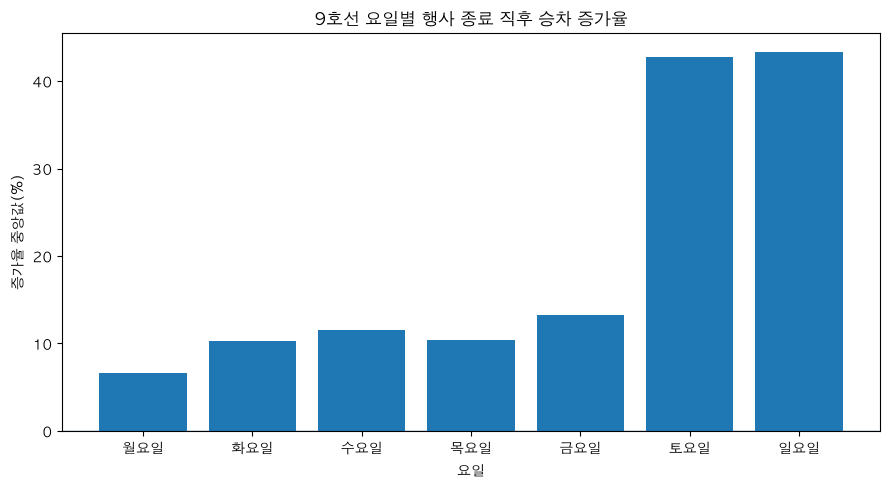

In [94]:
# 9호선 요일별 행사 종료 직후 승차 증가율 중앙값

plot_data = weekday_summary[
    weekday_summary['호선'] == '9호선'
].copy()

plt.figure(figsize=(9, 5))

plt.bar(
    plot_data['요일'].astype(str),
    plot_data['증가율중앙값']
)

plt.axhline(0, linewidth=1)

plt.title('9호선 요일별 행사 종료 직후 승차 증가율')
plt.xlabel('요일')
plt.ylabel('증가율 중앙값(%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [95]:
# 요일/행사종료시각 비교

daily_time_result = (
    matched.groupby(
        ['수송일자', '연도', '요일', '호선', '승하차구분', '종료시'],
        observed=True
    )
    .agg(
        행사일인원=('승하차인원', 'sum'),
        비행사일기준=('비행사일평균', 'sum')
    )
    .reset_index()
)

daily_time_result['차이'] = (
    daily_time_result['행사일인원'] -
    daily_time_result['비행사일기준']
)

daily_time_result['증가율'] = (
    daily_time_result['차이'] /
    daily_time_result['비행사일기준'] * 100
)

daily_time_result[
    ['수송일자', '요일', '호선', '승하차구분', '종료시',
     '행사일인원', '비행사일기준', '차이', '증가율']
].head(10)

,수송일자,요일,호선,승하차구분,종료시,행사일인원,비행사일기준,차이,증가율
0,2022-01-07,금요일,2호선,승차,21.0,605,2648.571429,-2043.571429,-77.157497
1,2022-01-07,금요일,2호선,하차,21.0,815,846.071429,-31.071429,-3.672436
2,2022-01-07,금요일,9호선,승차,21.0,455,450.785714,4.214286,0.934876
3,2022-01-07,금요일,9호선,하차,21.0,436,385.000000,51.000000,13.246753
4,2022-01-09,일요일,2호선,승차,17.0,675,1498.000000,-823.000000,-54.939920
5,2022-01-09,일요일,2호선,하차,17.0,572,687.090909,-115.090909,-16.750463
6,2022-01-09,일요일,9호선,승차,17.0,441,265.727273,175.272727,65.959631
7,2022-01-09,일요일,9호선,하차,17.0,292,315.000000,-23.000000,-7.301587
8,2022-01-12,수요일,2호선,승차,21.0,560,1331.157895,-771.157895,-57.931362
9,2022-01-12,수요일,2호선,하차,21.0,808,716.263158,91.736842,12.807701


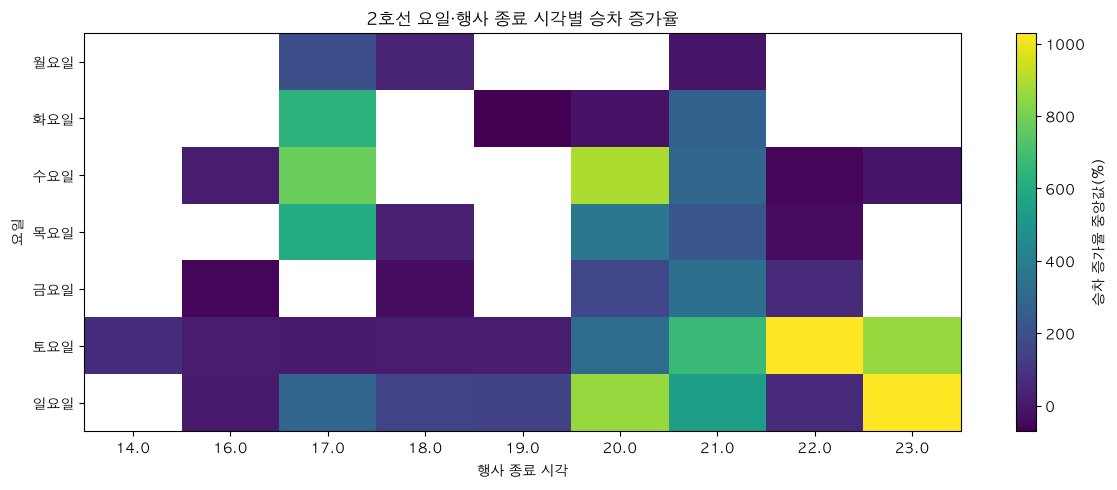

In [ ]:
# 2호선 요일/종료 시각별 승차 증가율 히트맵 (중앙값)
# 행사별 증가율은 비행사일 기준 수요가 작은 경우 극단적으로 커질 수 있어, 대표적인 증가 수준은 중앙값으로 제시하고 평균 증가 인원을 함께 확인

heat_data = daily_time_result[
    (daily_time_result['호선'] == '2호선') &
    (daily_time_result['승하차구분'] == '승차')
].copy()

heat_table = heat_data.pivot_table(
    index='요일',
    columns='종료시',
    values='증가율',
    aggfunc='median',
    observed=True
)

heat_table = heat_table.reindex(weekday_order)

plt.figure(figsize=(12, 5))

plt.imshow(
    heat_table,
    aspect='auto'
)

plt.colorbar(label='승차 증가율 중앙값(%)')

plt.title('2호선 요일·행사 종료 시각별 승차 증가율')
plt.xlabel('행사 종료 시각')
plt.ylabel('요일')

plt.xticks(
    range(len(heat_table.columns)),
    heat_table.columns
)

plt.yticks(
    range(len(heat_table.index)),
    heat_table.index
)

plt.tight_layout()
plt.show()

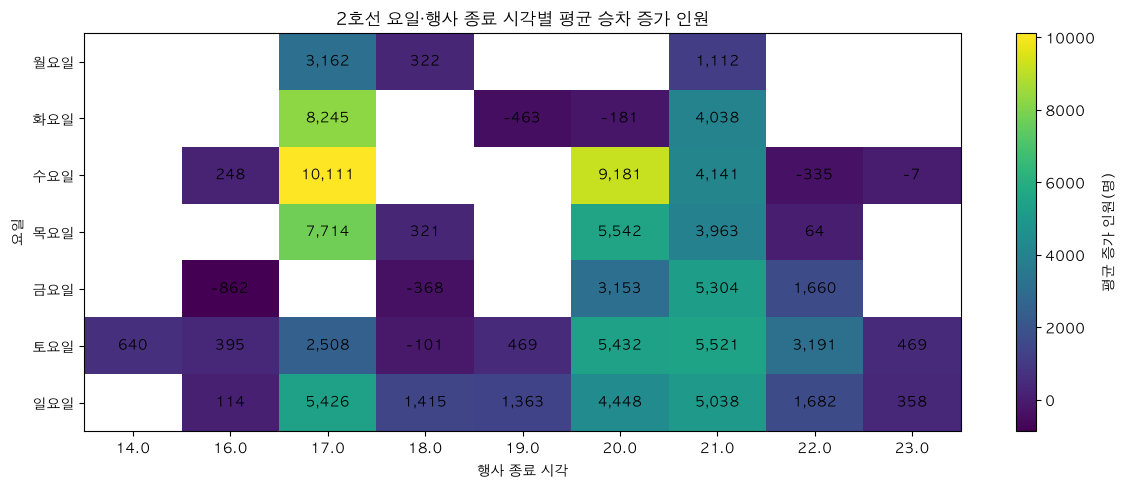

In [97]:
# 2호선 요일별 평균 증가 인원 히트맵

increase_table = heat_data.pivot_table(
    index='요일',
    columns='종료시',
    values='차이',
    aggfunc='mean',
    observed=True
)

increase_table = increase_table.reindex(weekday_order)

increase_table.round(0)

plt.figure(figsize=(12, 5))

plt.imshow(
    increase_table,
    aspect='auto'
)

plt.colorbar(label='평균 증가 인원(명)')

for i in range(len(increase_table.index)):
    for j in range(len(increase_table.columns)):
        value = increase_table.iloc[i, j]

        if pd.notna(value):
            plt.text(
                j,
                i,
                f'{value:,.0f}',
                ha='center',
                va='center'
            )

plt.title('2호선 요일·행사 종료 시각별 평균 승차 증가 인원')
plt.xlabel('행사 종료 시각')
plt.ylabel('요일')

plt.xticks(
    range(len(increase_table.columns)),
    increase_table.columns
)

plt.yticks(
    range(len(increase_table.index)),
    increase_table.index
)

plt.tight_layout()
plt.show()


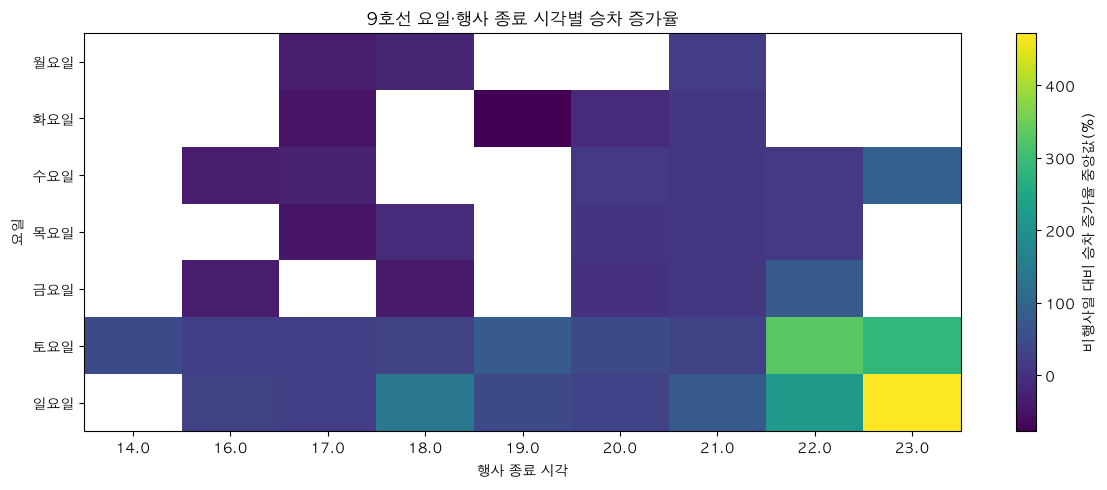

In [98]:
# 9호선 요일/행사 종료 시각별 승차 증가율 히트맵 (중앙값)

heat_data_9 = daily_time_result[
    (daily_time_result['호선'] == '9호선') &
    (daily_time_result['승하차구분'] == '승차')
].copy()

heat_table_9 = heat_data_9.pivot_table(
    index='요일',
    columns='종료시',
    values='증가율',
    aggfunc='median',
    observed=True
)

heat_table_9 = heat_table_9.reindex(weekday_order)

plt.figure(figsize=(12, 5))

plt.imshow(
    heat_table_9,
    aspect='auto'
)

plt.colorbar(label='비행사일 대비 승차 증가율 중앙값(%)')

plt.title('9호선 요일·행사 종료 시각별 승차 증가율')
plt.xlabel('행사 종료 시각')
plt.ylabel('요일')

plt.xticks(
    range(len(heat_table_9.columns)),
    heat_table_9.columns
)

plt.yticks(
    range(len(heat_table_9.index)),
    heat_table_9.index
)

plt.tight_layout()
plt.show()

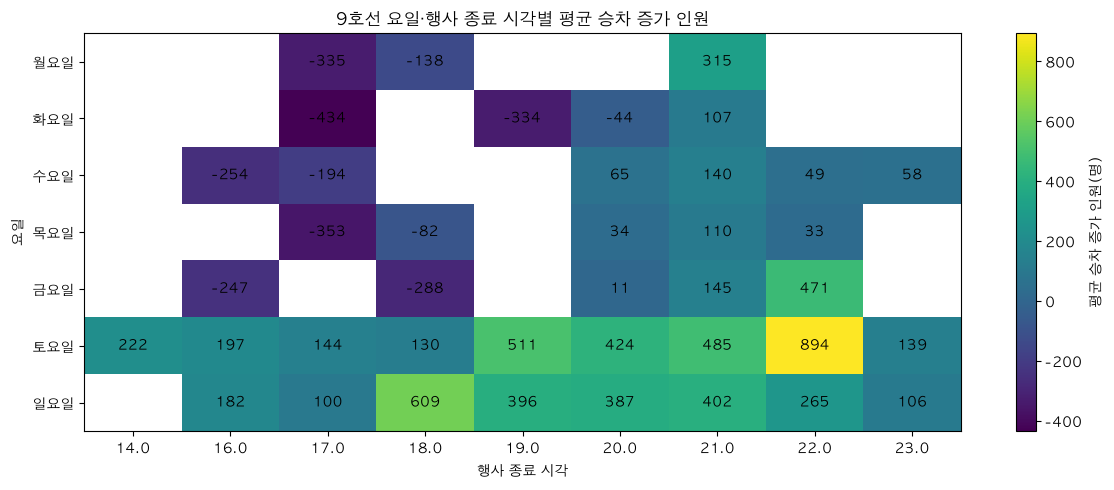

In [99]:
# 9호선 요일/행사 종료 시각별 평균 승차 인원 히트맵

increase_table_9 = heat_data_9.pivot_table(
    index='요일',
    columns='종료시',
    values='차이',
    aggfunc='mean',
    observed=True
)

increase_table_9 = increase_table_9.reindex(weekday_order)

increase_table_9.round(0)

plt.figure(figsize=(12, 5))

plt.imshow(
    increase_table_9,
    aspect='auto'
)

plt.colorbar(label='평균 승차 증가 인원(명)')

for i in range(len(increase_table_9.index)):
    for j in range(len(increase_table_9.columns)):
        value = increase_table_9.iloc[i, j]

        if pd.notna(value):
            plt.text(
                j,
                i,
                f'{value:,.0f}',
                ha='center',
                va='center'
            )

plt.title('9호선 요일·행사 종료 시각별 평균 승차 증가 인원')
plt.xlabel('행사 종료 시각')
plt.ylabel('요일')

plt.xticks(
    range(len(increase_table_9.columns)),
    increase_table_9.columns
)

plt.yticks(
    range(len(increase_table_9.index)),
    increase_table_9.index
)

plt.tight_layout()
plt.show()

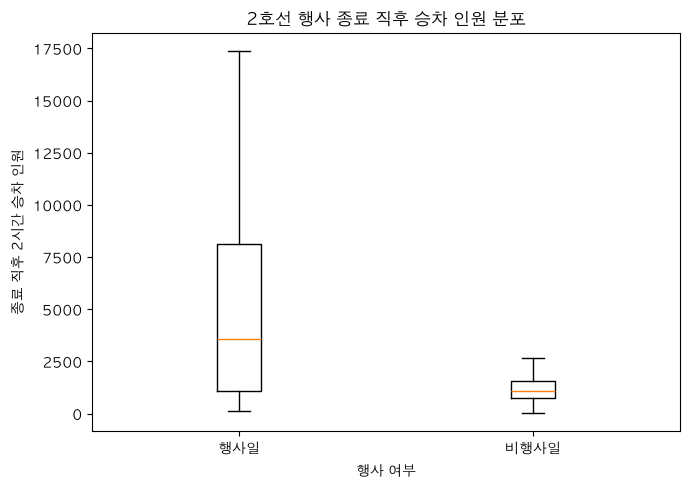

In [101]:
# 2호선 승차 인원 분포 확인

test_data_2 = daily_result[
    (daily_result['호선'] == '2호선') &
    (daily_result['승하차구분'] == '승차')
].copy()

plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        test_data_2['행사일인원'],
        test_data_2['비행사일기준']
    ],
    showfliers=False
)

plt.xticks([1, 2], ['행사일', '비행사일'])

plt.title('2호선 행사 종료 직후 승차 인원 분포')
plt.xlabel('행사 여부')
plt.ylabel('종료 직후 2시간 승차 인원')
plt.tight_layout()
plt.show()

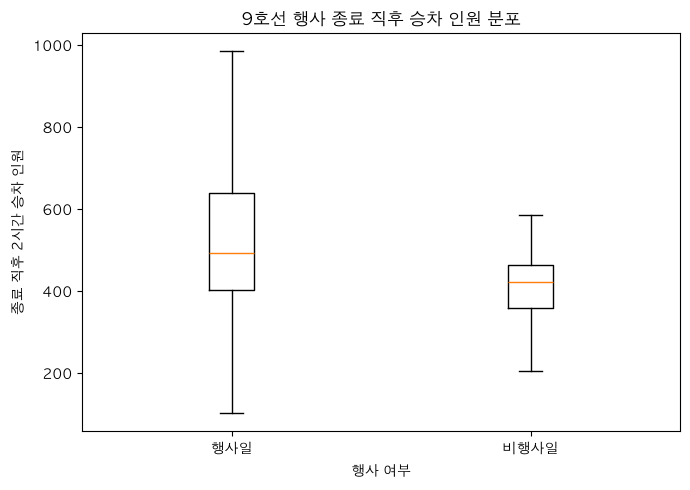

In [102]:
# 9호선 승차 인원 비교

test_data_9 = daily_result[
    (daily_result['호선'] == '9호선') &
    (daily_result['승하차구분'] == '승차')
].copy()

plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        test_data_9['행사일인원'],
        test_data_9['비행사일기준']
    ],
    showfliers=False
)

plt.xticks([1, 2], ['행사일', '비행사일'])

plt.title('9호선 행사 종료 직후 승차 인원 분포')
plt.xlabel('행사 여부')
plt.ylabel('종료 직후 2시간 승차 인원')
plt.tight_layout()
plt.show()

In [104]:
# 총 요약

part1_summary = time_summary[
    time_summary['승하차구분'] == '승차'
][[
    '호선', '상대시간대', '행사일평균', '비행사일평균',
    '평균차이', '증가율중앙값', '행사일우위비율', '표본수'
]].copy()

part1_summary.round(2)

,호선,상대시간대,행사일평균,비행사일평균,평균차이,증가율중앙값,행사일우위비율,표본수
0,2호선,종료 포함 시간대,3130.90,749.86,2381.05,157.11,74.62,863
1,2호선,종료 후 1시간대,1844.66,436.66,1408.00,81.69,66.16,863
4,9호선,종료 포함 시간대,317.69,232.21,85.48,9.42,65.35,863
5,9호선,종료 후 1시간대,317.86,181.70,136.16,24.52,77.40,863


행사 종료 직후 종합운동장역의 승차 수요는 비행사일보다 증가하는 경향이 나타났다. 특히 2호선은 행사 종료가 포함된 시간대에 평균 약 2,381명이 증가하고, 증가율 중앙값이 약 157.1%로 가장 큰 승차 수요가 집중되었다. 종료 후 다음 시간대에도 평균 약 1,408명의 추가 승차가 발생해 수요 증가가 이어졌다. 9호선은 2호선보다 증가 규모가 작았지만, 종료 후 다음 시간대에 증가가 더 크게 나타나 수요가 비교적 늦게까지 이어지는 경향이 관찰되었다.

### 하차

In [105]:
# 행사 시작 전 하차 데이터 만들기

start_rows = df[
    (df['행사여부'] == '행사일') &
    (df['승하차구분'] == '하차')
].copy()

start_rows['상대시간대'] = None

start_rows.loc[
    start_rows['시간대시작'] == start_rows['시작시'] - 1,
    '상대시간대'
] = '시작 전 1시간대'

start_rows.loc[
    start_rows['시간대시작'] == start_rows['시작시'],
    '상대시간대'
] = '시작 포함 시간대'

start_window = start_rows[
    start_rows['상대시간대'].notna()
].copy()



In [106]:
# 비행사일 평균과 연결

start_matched = start_window.merge(
    baseline,
    on=['연도', '요일', '호선', '승하차구분', '시간대'],
    how='left'
)

In [107]:
# 차이와 증가율 계산

start_matched['차이'] = (
    start_matched['승하차인원'] -
    start_matched['비행사일평균']
)

start_matched['증가율'] = np.where(
    start_matched['비행사일평균'] > 0,
    start_matched['차이'] /
    start_matched['비행사일평균'] * 100,
    np.nan
)

start_matched['행사일우위'] = start_matched['차이'] > 0

In [108]:
# 하차 결과 요약

start_summary = (
    start_matched.groupby(
        ['호선', '상대시간대'],
        observed=True
    )
    .agg(
        행사일평균=('승하차인원', 'mean'),
        비행사일평균=('비행사일평균', 'mean'),
        평균차이=('차이', 'mean'),
        증가율중앙값=('증가율', 'median'),
        행사일우위비율=('행사일우위', 'mean'),
        표본수=('수송일자', 'count')
    )
    .reset_index()
)

start_summary['행사일우위비율'] *= 100

start_summary.round(2)

,호선,상대시간대,행사일평균,비행사일평균,평균차이,증가율중앙값,행사일우위비율,표본수
0,2호선,시작 전 1시간대,3090.10,1029.13,2060.97,131.81,81.09,862
1,2호선,시작 포함 시간대,2283.69,972.48,1311.21,75.18,78.79,863
2,9호선,시작 전 1시간대,467.09,370.05,97.03,21.25,88.98,862
3,9호선,시작 포함 시간대,477.43,423.51,53.93,10.93,80.07,863


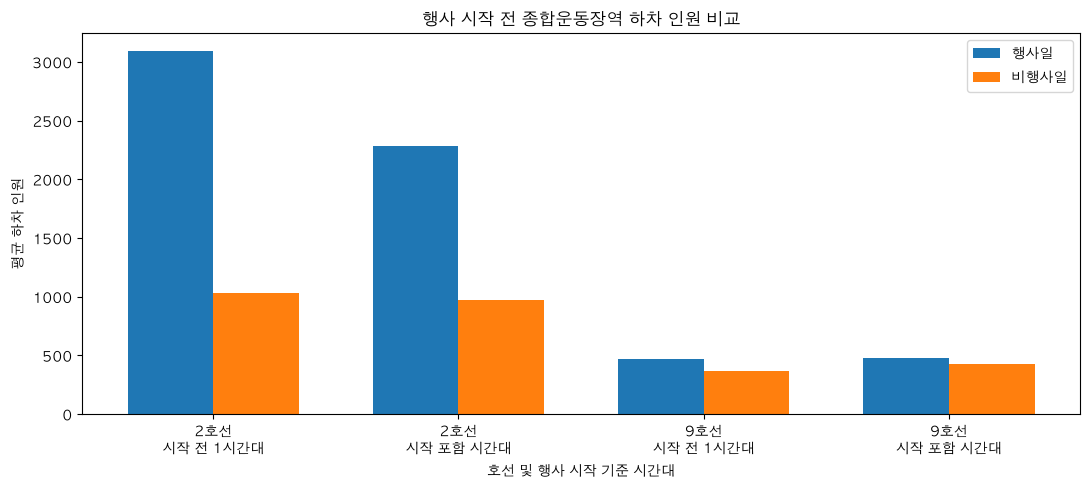

In [109]:
# 행사 시작 전 하차 인원 비교 그래프

start_time_order = ['시작 전 1시간대', '시작 포함 시간대']

start_summary['상대시간대'] = pd.Categorical(
    start_summary['상대시간대'],
    categories=start_time_order,
    ordered=True
)

start_plot = start_summary.sort_values(
    ['호선', '상대시간대']
).copy()

start_plot['구분'] = (
    start_plot['호선'] + '\n' +
    start_plot['상대시간대'].astype(str)
)

x = np.arange(len(start_plot))
width = 0.35

plt.figure(figsize=(11, 5))

plt.bar(
    x - width / 2,
    start_plot['행사일평균'],
    width,
    label='행사일'
)

plt.bar(
    x + width / 2,
    start_plot['비행사일평균'],
    width,
    label='비행사일'
)

plt.title('행사 시작 전 종합운동장역 하차 인원 비교')
plt.xlabel('호선 및 행사 시작 기준 시간대')
plt.ylabel('평균 하차 인원')
plt.xticks(x, start_plot['구분'])
plt.legend()
plt.tight_layout()
plt.show()

In [110]:
# 행사별 시작 전 하차 인원 합계

daily_start_result = (
    start_matched.groupby(
        ['수송일자', '연도', '요일', '호선', '시작시'],
        observed=True
    )
    .agg(
        행사일인원=('승하차인원', 'sum'),
        비행사일기준=('비행사일평균', 'sum')
    )
    .reset_index()
)

daily_start_result['차이'] = (
    daily_start_result['행사일인원'] -
    daily_start_result['비행사일기준']
)

daily_start_result['증가율'] = (
    daily_start_result['차이'] /
    daily_start_result['비행사일기준'] * 100
)



In [116]:
# 요일/호선별 하차 증가율 요약

start_weekday_summary = (
    daily_start_result.groupby(
        ['요일', '호선'],
        observed=True
    )
    .agg(
        증가율중앙값=('증가율', 'median'),
        평균증가인원=('차이', 'mean'),
        표본수=('수송일자', 'count')
    )
    .reset_index()
)

start_weekday_summary

,요일,호선,증가율중앙값,평균증가인원,표본수
0,월요일,2호선,18.374156,1679.817774,22
1,월요일,9호선,10.935606,79.806594,22
2,화요일,2호선,148.643395,4339.262792,104
3,화요일,9호선,11.836232,143.262417,104
4,수요일,2호선,95.843531,3398.570892,131
5,수요일,9호선,14.988943,150.745902,131
6,목요일,2호선,83.557642,3252.887084,143
7,목요일,9호선,11.671603,103.424626,143
8,금요일,2호선,85.348328,3793.501849,142
9,금요일,9호선,14.733475,176.877653,142


In [122]:
# 2호선 요일/행사 시작 시각별 평균 증가 인원

start_heat_data_2 = daily_start_result[
    daily_start_result['호선'] == '2호선'
].copy()

start_increase_table_2 = start_heat_data_2.pivot_table(
    index='요일',
    columns='시작시',
    values='차이',
    aggfunc='median',
    observed=True
)

start_increase_table_2 = start_increase_table_2.reindex(weekday_order)

start_increase_table_2.round(0)

시작시,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0
요일,,,,,,,,,,,,,,,,
월요일,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-126.0,6319.0,NaN,481.0,NaN,12154.0,89.0,1208.0
화요일,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8226.0,NaN,NaN,-790.0,4944.0,-239.0,1300.0
수요일,NaN,NaN,229.0,NaN,518.0,NaN,NaN,NaN,NaN,4032.0,NaN,NaN,6589.0,4250.0,160.0,195.0
목요일,NaN,NaN,NaN,NaN,NaN,-36.0,NaN,NaN,NaN,3287.0,NaN,NaN,4110.0,5028.0,68.0,108.0
금요일,NaN,25.0,142.0,304.0,651.0,-66.0,NaN,2297.0,360.0,789.0,2560.0,-341.0,4454.0,6657.0,19.0,138.0
토요일,NaN,89.0,70.0,185.0,187.0,332.0,-138.0,598.0,1293.0,1787.0,955.0,10.0,6920.0,5024.0,-71.0,NaN
일요일,-9.0,111.0,-302.0,-387.0,104.0,852.0,NaN,1629.0,3400.0,1077.0,140.0,460.0,3880.0,1495.0,64.0,NaN


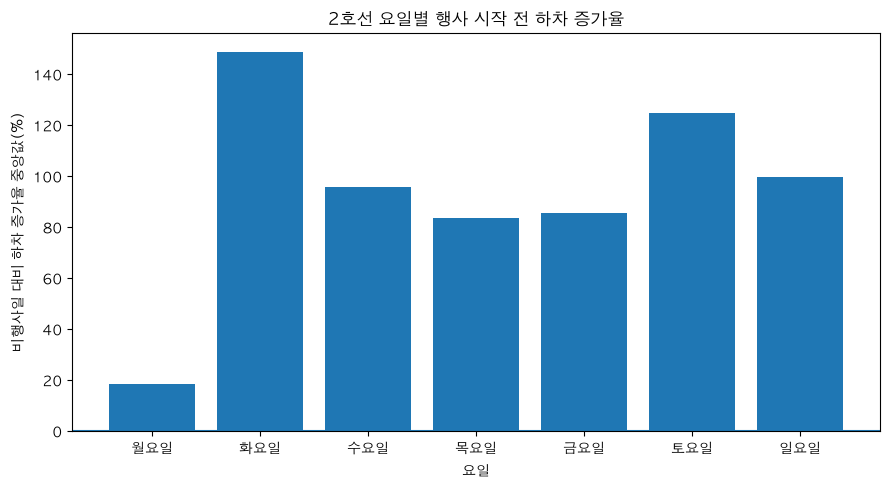

In [117]:
# 지호선 요일별 하차 증가율 막대그래프

start_weekday_2 = start_weekday_summary[
    start_weekday_summary['호선'] == '2호선'
].copy()

start_weekday_2 = start_weekday_2.sort_values('요일')

plt.figure(figsize=(9, 5))

plt.bar(
    start_weekday_2['요일'],
    start_weekday_2['증가율중앙값']
)

plt.axhline(0)

plt.title('2호선 요일별 행사 시작 전 하차 증가율')
plt.xlabel('요일')
plt.ylabel('비행사일 대비 하차 증가율 중앙값(%)')
plt.tight_layout()
plt.show()

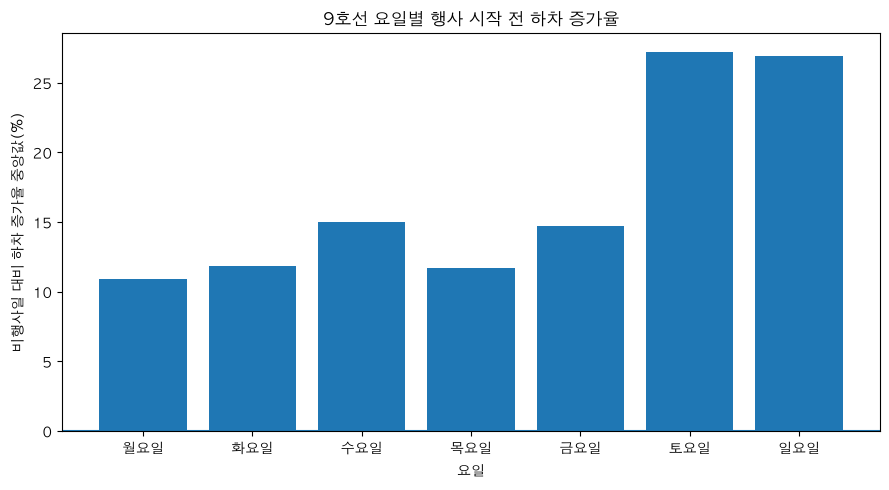

In [118]:
# 9호선 요일별 하차 증가율 막대그래프

start_weekday_9 = start_weekday_summary[
    start_weekday_summary['호선'] == '9호선'
].copy()

start_weekday_9 = start_weekday_9.sort_values('요일')

plt.figure(figsize=(9, 5))

plt.bar(
    start_weekday_9['요일'],
    start_weekday_9['증가율중앙값']
)

plt.axhline(0)

plt.title('9호선 요일별 행사 시작 전 하차 증가율')
plt.xlabel('요일')
plt.ylabel('비행사일 대비 하차 증가율 중앙값(%)')
plt.tight_layout()
plt.show()

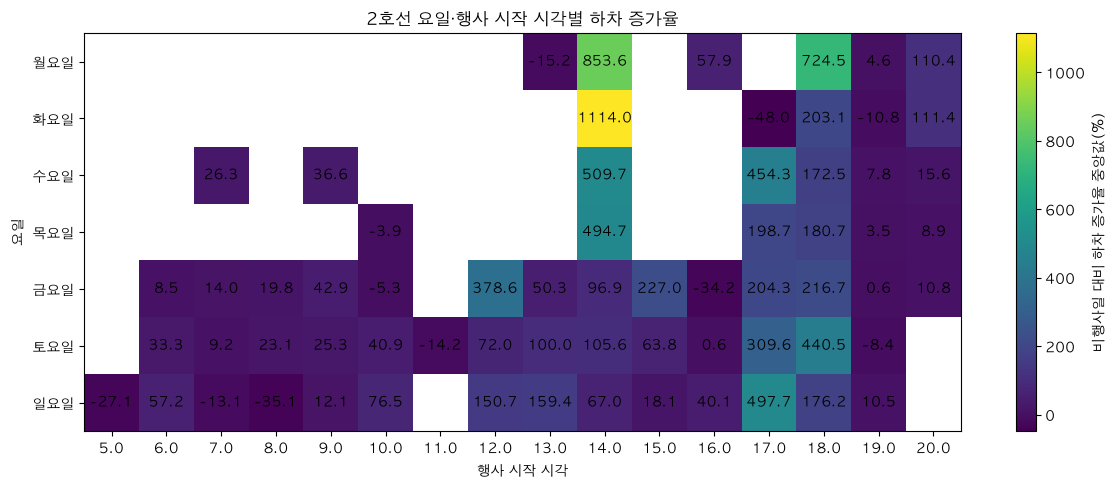

In [120]:
# 2호선 요일/행사 시작 시각별 하차 증가율 히트맵 (중앙값)

start_rate_table_2 = start_heat_data_2.pivot_table(
    index='요일',
    columns='시작시',
    values='증가율',
    aggfunc='median',
    observed=True
)

start_rate_table_2 = start_rate_table_2.reindex(weekday_order)

start_rate_table_2.round(2)

plt.figure(figsize=(12, 5))

plt.imshow(
    start_rate_table_2,
    aspect='auto'
)

plt.colorbar(label='비행사일 대비 하차 증가율 중앙값(%)')

for i in range(len(start_rate_table_2.index)):
    for j in range(len(start_rate_table_2.columns)):
        value = start_rate_table_2.iloc[i, j]

        if pd.notna(value):
            plt.text(
                j,
                i,
                f'{value:.1f}',
                ha='center',
                va='center'
            )

plt.title('2호선 요일·행사 시작 시각별 하차 증가율')
plt.xlabel('행사 시작 시각')
plt.ylabel('요일')

plt.xticks(
    range(len(start_rate_table_2.columns)),
    start_rate_table_2.columns
)

plt.yticks(
    range(len(start_rate_table_2.index)),
    start_rate_table_2.index
)

plt.tight_layout()
plt.show()

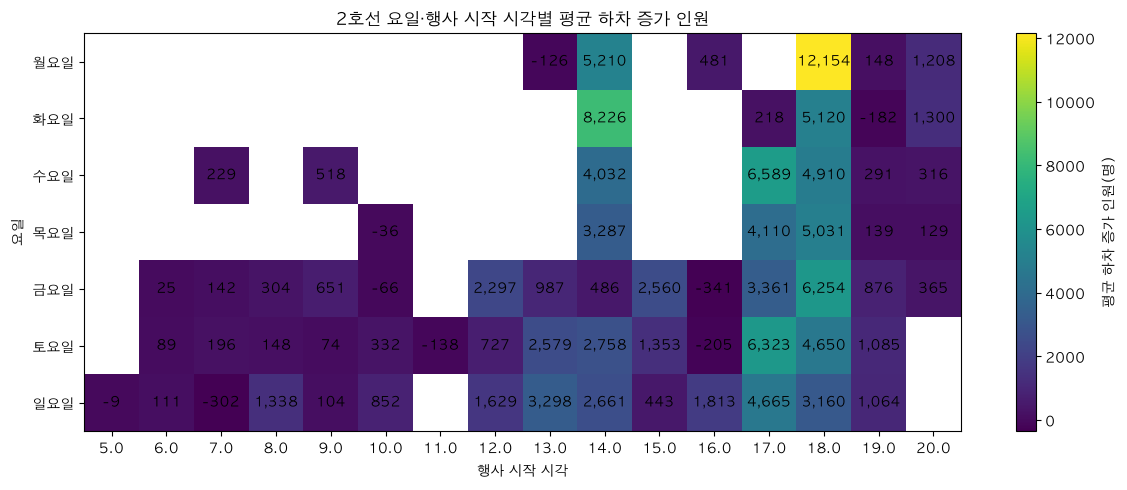

In [119]:
# 2호선 요일/행사 시작 시각별 평균 하차 증가 인원 히트맵

start_increase_table_2 = start_heat_data_2.pivot_table(
    index='요일',
    columns='시작시',
    values='차이',
    aggfunc='mean',
    observed=True
)

start_increase_table_2 = start_increase_table_2.reindex(weekday_order)

start_increase_table_2.round(0)

plt.figure(figsize=(12, 5))

plt.imshow(
    start_increase_table_2,
    aspect='auto'
)

plt.colorbar(label='평균 하차 증가 인원(명)')

for i in range(len(start_increase_table_2.index)):
    for j in range(len(start_increase_table_2.columns)):
        value = start_increase_table_2.iloc[i, j]

        if pd.notna(value):
            plt.text(
                j,
                i,
                f'{value:,.0f}',
                ha='center',
                va='center'
            )

plt.title('2호선 요일·행사 시작 시각별 평균 하차 증가 인원')
plt.xlabel('행사 시작 시각')
plt.ylabel('요일')

plt.xticks(
    range(len(start_increase_table_2.columns)),
    start_increase_table_2.columns
)

plt.yticks(
    range(len(start_increase_table_2.index)),
    start_increase_table_2.index
)

plt.tight_layout()
plt.show()

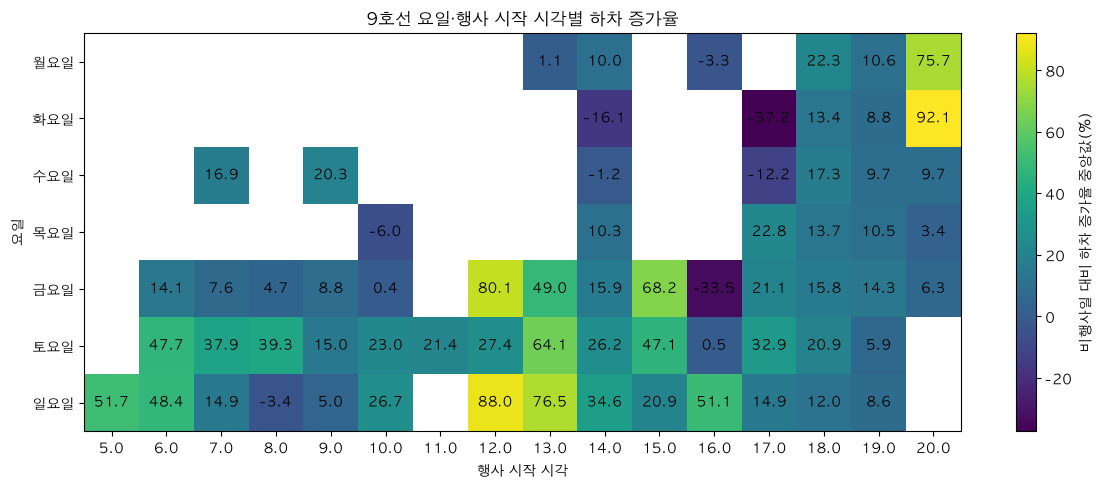

In [123]:
# 9호선 하차 증가율 히트맵 (중앙값)

start_heat_data_9 = daily_start_result[
    daily_start_result['호선'] == '9호선'
].copy()

start_rate_table_9 = start_heat_data_9.pivot_table(
    index='요일',
    columns='시작시',
    values='증가율',
    aggfunc='median',
    observed=True
)

start_rate_table_9 = start_rate_table_9.reindex(weekday_order)

plt.figure(figsize=(12, 5))

plt.imshow(
    start_rate_table_9,
    aspect='auto'
)

plt.colorbar(label='비행사일 대비 하차 증가율 중앙값(%)')

for i in range(len(start_rate_table_9.index)):
    for j in range(len(start_rate_table_9.columns)):
        value = start_rate_table_9.iloc[i, j]

        if pd.notna(value):
            plt.text(
                j,
                i,
                f'{value:.1f}',
                ha='center',
                va='center'
            )

plt.title('9호선 요일·행사 시작 시각별 하차 증가율')
plt.xlabel('행사 시작 시각')
plt.ylabel('요일')

plt.xticks(
    range(len(start_rate_table_9.columns)),
    start_rate_table_9.columns
)

plt.yticks(
    range(len(start_rate_table_9.index)),
    start_rate_table_9.index
)

plt.tight_layout()
plt.show()

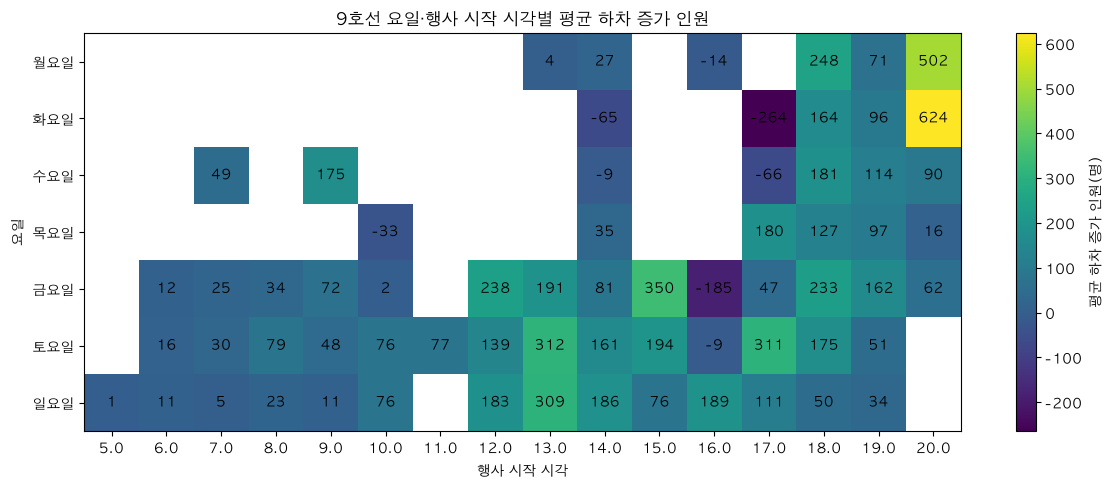

In [125]:
# 9호선 요일/행사 시작 시각별 평균 하차 증가 인원 히트맵

start_increase_table_9 = start_heat_data_9.pivot_table(
    index='요일',
    columns='시작시',
    values='차이',
    aggfunc='mean',
    observed=True
)

start_increase_table_9 = start_increase_table_9.reindex(weekday_order)

plt.figure(figsize=(12, 5))

plt.imshow(
    start_increase_table_9,
    aspect='auto'
)

plt.colorbar(label='평균 하차 증가 인원(명)')

for i in range(len(start_increase_table_9.index)):
    for j in range(len(start_increase_table_9.columns)):
        value = start_increase_table_9.iloc[i, j]

        if pd.notna(value):
            plt.text(
                j,
                i,
                f'{value:,.0f}',
                ha='center',
                va='center'
            )

plt.title('9호선 요일·행사 시작 시각별 평균 하차 증가 인원')
plt.xlabel('행사 시작 시각')
plt.ylabel('요일')

plt.xticks(
    range(len(start_increase_table_9.columns)),
    start_increase_table_9.columns
)

plt.yticks(
    range(len(start_increase_table_9.index)),
    start_increase_table_9.index
)

plt.tight_layout()
plt.show()

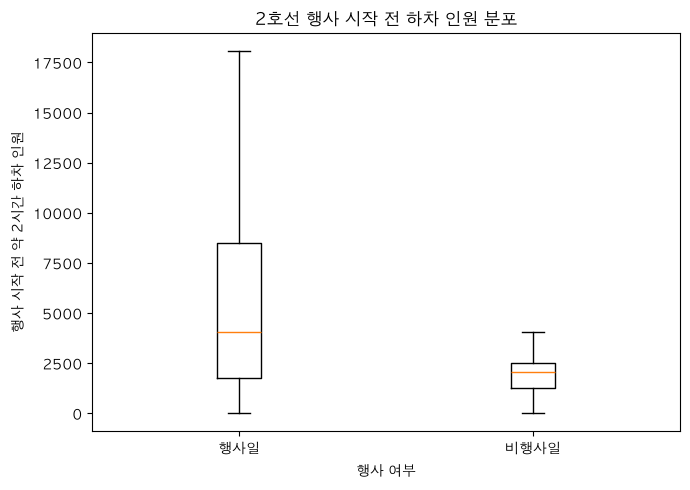

In [126]:
# 2호선 행사 시작 전 하차 인원 분포

start_test_data_2 = daily_start_result[
    daily_start_result['호선'] == '2호선'
].dropna(
    subset=['행사일인원', '비행사일기준']
).copy()

plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        start_test_data_2['행사일인원'],
        start_test_data_2['비행사일기준']
    ],
    showfliers=False
)

plt.xticks([1, 2], ['행사일', '비행사일'])

plt.title('2호선 행사 시작 전 하차 인원 분포')
plt.xlabel('행사 여부')
plt.ylabel('행사 시작 전 약 2시간 하차 인원')
plt.tight_layout()
plt.show()



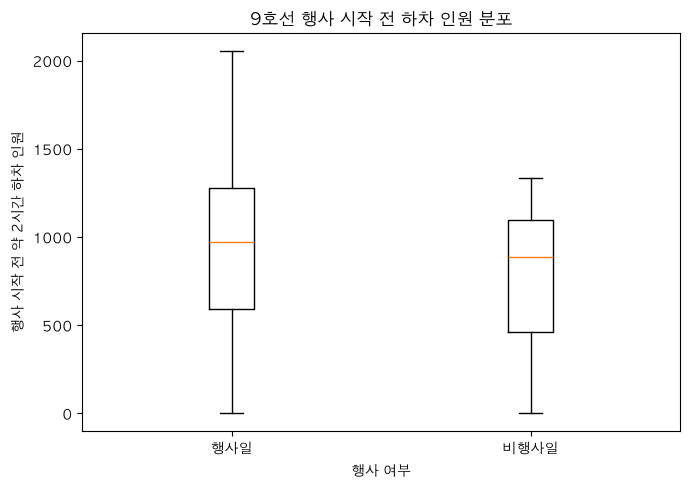

In [127]:
# 9호선 행사 시작 전 하차 인원 분포

start_test_data_9 = daily_start_result[
    daily_start_result['호선'] == '9호선'
].dropna(
    subset=['행사일인원', '비행사일기준']
).copy()

plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        start_test_data_9['행사일인원'],
        start_test_data_9['비행사일기준']
    ],
    showfliers=False
)

plt.xticks([1, 2], ['행사일', '비행사일'])

plt.title('9호선 행사 시작 전 하차 인원 분포')
plt.xlabel('행사 여부')
plt.ylabel('행사 시작 전 약 2시간 하차 인원')
plt.tight_layout()
plt.show()

In [128]:
# 하차 분석 최종 요약

part1_start_summary = start_summary[[
    '호선', '상대시간대', '행사일평균', '비행사일평균',
    '평균차이', '증가율중앙값', '행사일우위비율', '표본수'
]].copy()

part1_start_summary = part1_start_summary.sort_values(
    ['호선', '상대시간대']
)

part1_start_summary.round(2)

,호선,상대시간대,행사일평균,비행사일평균,평균차이,증가율중앙값,행사일우위비율,표본수
0,2호선,시작 전 1시간대,3090.10,1029.13,2060.97,131.81,81.09,862
1,2호선,시작 포함 시간대,2283.69,972.48,1311.21,75.18,78.79,863
2,9호선,시작 전 1시간대,467.09,370.05,97.03,21.25,88.98,862
3,9호선,시작 포함 시간대,477.43,423.51,53.93,10.93,80.07,863


하차 결론: 행사 시작 전 종합운동장역의 하차 수요는 비행사일보다 증가하는 경향이 나타났다. 특히 2호선은 행사 시작 전 1시간대에 평균 약 2,061명이 증가했으며, 증가율 중앙값은 약 131.8%로 가장 큰 유입이 확인되었다. 9호선도 대부분의 행사에서 하차 인원이 증가했지만, 평균 증가 규모는 2호선보다 상대적으로 작았다. 따라서 행사 전 관람객 유입은 2호선에 집중되며, 특히 행사 시작 1시간 전이 주요 관리 시간대로 판단된다.

승하차 합친 결론 : 행사 시작 전에는 2호선 하차 수요가 크게 증가했고, 행사 종료 후에는 2호선 승차 수요가 크게 증가했다. 특히 행사 시작 전 1시간대와 행사 종료가 포함된 시간대에 수요가 가장 집중됐다. 9호선도 행사에 따른 수요 증가가 나타났지만, 증가 규모는 2호선보다 작았으며 종료 후 승차 수요는 다음 시간대에 상대적으로 더 크게 나타났다.

### 혼잡도 데이터랑 연결해보기

In [130]:
congestion = congestion_df[
    congestion_df['연도'].between(2022, 2025)
].copy()

congestion['시간대시작'] = (
    congestion['시간대'].str[:2].astype(int)
)

congestion['시간대_승하차'] = np.where(
    congestion['시간대시작'] == 0,
    '24시이후',
    congestion['시간대시작'].astype(str).str.zfill(2)
    + '-'
    + (congestion['시간대시작'] + 1).astype(str).str.zfill(2)
    + '시간대'
)

congestion[[
    '시간대시작', '시간대', '시간대_승하차'
]].drop_duplicates().sort_values('시간대시작')

,시간대시작,시간대,시간대_승하차
592,0,00:00~00:59,24시이후
96,12,12:00~12:59,12-13시간대
97,13,13:00~13:59,13-14시간대
98,14,14:00~14:59,14-15시간대
99,15,15:00~15:59,15-16시간대
100,16,16:00~16:59,16-17시간대
101,17,17:00~17:59,17-18시간대
102,18,18:00~18:59,18-19시간대
103,19,19:00~19:59,19-20시간대
104,20,20:00~20:59,20-21시간대


In [131]:
# 방향, 시간대별 기준 혼잡도 표

congestion_reference = (
    congestion.groupby(
        ['연도', '요일구분', '호선', '시간대_승하차'],
        observed=True
    )
    .agg(
        평균혼잡도=('혼잡도', 'mean'),
        최대혼잡도=('혼잡도', 'max')
    )
    .reset_index()
)

congestion_reference.head()


,연도,요일구분,호선,시간대_승하차,평균혼잡도,최대혼잡도
0,2022,주말,2호선,12-13시간대,31.9875,32.400
1,2022,주말,2호선,13-14시간대,33.7375,36.325
2,2022,주말,2호선,14-15시간대,33.3375,35.850
3,2022,주말,2호선,15-16시간대,38.0750,44.250
4,2022,주말,2호선,16-17시간대,42.2750,49.050


In [132]:
congestion_reference.shape

(200, 6)

In [133]:
congestion_reference[
    congestion_reference['호선'] == '2호선'
].head()

,연도,요일구분,호선,시간대_승하차,평균혼잡도,최대혼잡도
0,2022,주말,2호선,12-13시간대,31.9875,32.400
1,2022,주말,2호선,13-14시간대,33.7375,36.325
2,2022,주말,2호선,14-15시간대,33.3375,35.850
3,2022,주말,2호선,15-16시간대,38.0750,44.250
4,2022,주말,2호선,16-17시간대,42.2750,49.050


In [134]:
# 행사 종료 후 승차 데이터에 혼잡도 붙이기

matched['요일구분'] = np.where(
    matched['요일'].isin(['토요일', '일요일']),
    '주말',
    '평일'
)

matched_congestion = matched.merge(
    congestion_reference,
    left_on=['연도', '요일구분', '호선', '시간대'],
    right_on=['연도', '요일구분', '호선', '시간대_승하차'],
    how='left'
)

matched_congestion[[
    '수송일자', '요일', '요일구분', '호선',
    '상대시간대', '시간대', '승하차인원',
    '비행사일평균', '평균혼잡도', '최대혼잡도'
]].head()

,수송일자,요일,요일구분,호선,상대시간대,시간대,승하차인원,비행사일평균,평균혼잡도,최대혼잡도
0,2022-11-05,토요일,주말,2호선,종료 포함 시간대,14-15시간대,832,395.461538,33.3375,35.85
1,2022-11-05,토요일,주말,2호선,종료 포함 시간대,14-15시간대,704,692.076923,33.3375,35.85
2,2022-11-12,토요일,주말,2호선,종료 포함 시간대,14-15시간대,926,395.461538,33.3375,35.85
3,2022-11-12,토요일,주말,2호선,종료 포함 시간대,14-15시간대,741,692.076923,33.3375,35.85
4,2022-11-19,토요일,주말,2호선,종료 포함 시간대,14-15시간대,465,395.461538,33.3375,35.85


In [135]:
matched_congestion[[
    '평균혼잡도', '최대혼잡도'
]].isna().sum()

평균혼잡도    6
최대혼잡도    6
dtype: int64

In [136]:
missing_congestion = matched_congestion[
    matched_congestion['평균혼잡도'].isna()
][[
    '수송일자', '연도', '요일', '요일구분', '호선',
    '상대시간대', '시간대'
]].drop_duplicates()

missing_congestion

,수송일자,연도,요일,요일구분,호선,상대시간대,시간대
6892,2022-09-24,2022,토요일,주말,2호선,종료 후 1시간대,24시이후
6894,2022-09-25,2022,일요일,주말,2호선,종료 후 1시간대,24시이후
6896,2022-11-16,2022,수요일,평일,2호선,종료 후 1시간대,24시이후


In [137]:
print(missing_congestion.to_string(index=False))

      수송일자   연도  요일 요일구분  호선     상대시간대   시간대
2022-09-24 2022 토요일   주말 2호선 종료 후 1시간대 24시이후
2022-09-25 2022 일요일   주말 2호선 종료 후 1시간대 24시이후
2022-11-16 2022 수요일   평일 2호선 종료 후 1시간대 24시이후


In [138]:
missing_congestion.groupby(
    ['연도', '요일구분', '호선', '시간대']
).size().reset_index(name='누락행수')

,연도,요일구분,호선,시간대,누락행수
0,2022,주말,2호선,24시이후,2
1,2022,평일,2호선,24시이후,1


In [140]:
matched_congestion_valid = matched_congestion.dropna(
    subset=['평균혼잡도', '최대혼잡도']
).copy()

matched_congestion_valid[[
    '평균혼잡도', '최대혼잡도'
]].isna().sum()

평균혼잡도    0
최대혼잡도    0
dtype: int64

In [141]:
print('제외 전:', len(matched_congestion))
print('제외 후:', len(matched_congestion_valid))
print('제외 행 수:', len(matched_congestion) - len(matched_congestion_valid))

제외 전: 6904
제외 후: 6898
제외 행 수: 6


In [142]:
# 승차 수요 증가와 기준 혼잡도 요약

congestion_summary = (
    matched_congestion_valid[
        matched_congestion_valid['승하차구분'] == '승차'
    ]
    .groupby(
        ['호선', '상대시간대'],
        observed=True
    )
    .agg(
        행사일승차평균=('승하차인원', 'mean'),
        비행사일승차평균=('비행사일평균', 'mean'),
        평균증가인원=('차이', 'mean'),
        증가율중앙값=('증가율', 'median'),
        기준평균혼잡도=('평균혼잡도', 'mean'),
        기준최대혼잡도평균=('최대혼잡도', 'mean'),
        관측기준최대혼잡도=('최대혼잡도', 'max'),
        표본수=('증가율', 'count')
    )
    .reset_index()
)

congestion_summary.round(2)

,호선,상대시간대,행사일승차평균,비행사일승차평균,평균증가인원,증가율중앙값,기준평균혼잡도,기준최대혼잡도평균,관측기준최대혼잡도,표본수
0,2호선,종료 포함 시간대,3130.90,749.86,2381.05,157.11,38.03,47.12,89.44,863
1,2호선,종료 후 1시간대,1851.05,438.16,1412.89,81.53,33.10,41.86,89.44,860
2,9호선,종료 포함 시간대,317.69,232.21,85.48,9.42,28.59,41.19,84.99,863
3,9호선,종료 후 1시간대,317.86,181.70,136.16,24.52,24.86,36.39,84.99,863


평상시 열차 혼잡도는 평균적으로 여유가 있는 수준이지만, 행사 종료가 포함된 시간대에 2호선 승차 수요가 매우 크게 증가하므로 기존 여유 수송력만으로 수요를 처리할 수 있는지 추가 검토가 필요하다.

행사 종료 후 승차 수요와 평상시 기준 혼잡도를 함께 비교한 결과, 2호선의 행사 종료 포함 시간대가 가장 높은 운영 대응 우선순위를 보였다. 해당 시간대에는 비행사일보다 평균 약 2,381명이 추가로 승차했으며, 증가율 중앙값은 약 157.1%였다. 종료 후 다음 시간대에도 평균 약 1,413명의 추가 수요가 이어졌다. 9호선도 수요 증가가 관찰됐으나 절대 증가 규모가 상대적으로 작아 2호선보다 우선순위가 낮았다.

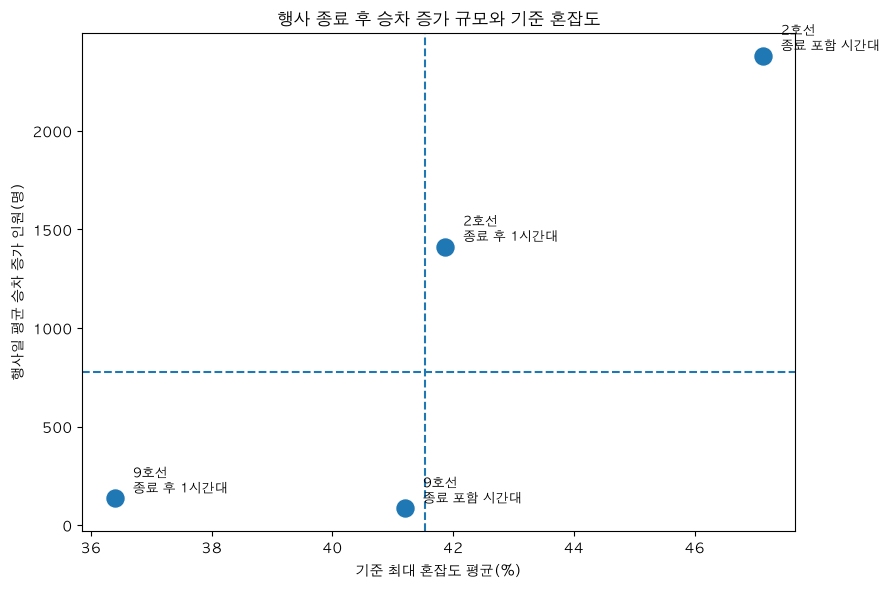

In [143]:
priority_plot = congestion_summary.copy()

plt.figure(figsize=(9, 6))

plt.scatter(
    priority_plot['기준최대혼잡도평균'],
    priority_plot['평균증가인원'],
    s=150
)

for i in range(len(priority_plot)):
    plt.text(
        priority_plot.loc[i, '기준최대혼잡도평균'] + 0.3,
        priority_plot.loc[i, '평균증가인원'] + 30,
        priority_plot.loc[i, '호선'] + '\n' + priority_plot.loc[i, '상대시간대'],
        fontsize=9
    )

x_median = priority_plot['기준최대혼잡도평균'].median()
y_median = priority_plot['평균증가인원'].median()

plt.axvline(
    x=x_median,
    linestyle='--'
)

plt.axhline(
    y=y_median,
    linestyle='--'
)

plt.title('행사 종료 후 승차 증가 규모와 기준 혼잡도')
plt.xlabel('기준 최대 혼잡도 평균(%)')
plt.ylabel('행사일 평균 승차 증가 인원(명)')
plt.tight_layout()
plt.show()